#1: Imports and Path Setup

In [1]:
import os
import sys
import time
import json
import csv
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT  = '/content/drive/MyDrive/Transformer_Mine'

In [3]:
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints')
LOG_DIR = os.path.join(PROJECT_ROOT, 'logs')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
EXPERIMENTS_DIR = os.path.join(PROJECT_ROOT, 'experiments')

In [4]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Transformer_Mine

Mounted at /content/drive
/content/drive/MyDrive/Transformer_Mine


In [5]:
from transformer_model import TiedTransformer
from data_pipeline import (
    load_raw_pairs,
    build_tf_dataset,
    create_padding_mask,
    create_decoder_mask,
)
from tokenizer import BPETokenizer

In [6]:
for d in [CHECKPOINT_DIR, LOG_DIR, RESULTS_DIR, EXPERIMENTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Project root:", PROJECT_ROOT)

TensorFlow: 2.20.0
Project root: /content/drive/MyDrive/Transformer_Mine


#2: Label Smoothing Loss

## Label Smoothing

From the paper, Section 5.4:

> "We employed label smoothing of value eps_ls = 0.1"

The Transformer uses **label smoothing** with:

```text
eps_ls = 0.1
```

### Standard Cross-Entropy Target

Standard cross-entropy uses a one-hot target distribution:

```text
target = [0, 0, 1, 0, 0, ...]
```

All probability mass is assigned to the correct token.

### Label-Smoothed Target

With label smoothing, a small amount of probability mass is distributed across all vocabulary tokens:

```text
target = [eps/(V-1), ..., 1-eps, ..., eps/(V-1)]
```

where:

* `eps` = label smoothing factor
* `V` = vocabulary size
* `1 - eps` = probability assigned to the correct token

For this implementation:

```text
eps = 0.1
```

### Why Label Smoothing Is Used

Label smoothing:

* Prevents the model from becoming excessively confident.
* Acts as a form of regularisation.
* Produces better-calibrated predictions.
* Improves translation quality and BLEU score according to the paper.

### Effect on Loss

The smoothed loss can be expressed as:

$$
L_{\text{smooth}}
=
(1-\epsilon)L_{\text{correct}}
+
\epsilon L_{\text{all}}
$$

or equivalently:

```text
smoothed_loss =
    (1 - eps) * cross_entropy(correct_token)
    + eps * mean(cross_entropy(all_tokens))
```

### Padding Mask

Padding positions must not contribute to the loss.

Since:

```text
PAD_ID = 0
```

positions where:

```text
target == PAD_ID
```

are masked out and contribute **zero loss**.

This is necessary because the model is not expected to learn to predict padding tokens.

### Implementation Approach

The loss is computed **manually** instead of using Keras:

```text
SparseCategoricalCrossentropy
```

This makes both components fully explicit:

1. **Label smoothing**
2. **Padding masking**

The overall process is:

```text
Target Tokens
      |
      ↓
Label Smoothing
      |
      ↓
Cross-Entropy with Logits
      |
      ↓
Padding Mask
      |
      ↓
Masked Mean Loss
```


In [7]:
PAD_ID = 0

In [19]:
def label_smoothing_loss(
    logits,
    targets,
    vocab_size,
    smoothing=0.1,
    pad_id=PAD_ID,
):
    """
    Cross-entropy loss with label smoothing and padding mask.

    Args:
        logits : (batch, tgt_len, vocab_size) — raw model output
        targets : (batch, tgt_len) — integer token IDs (decoder targets)
        vocab_size : integer — size of the vocabulary
        smoothing : float — label smoothing factor (paper: 0.1)
        pad_id : integer — padding token ID (excluded from loss)

    Returns:
        loss : scalar float — mean loss over non-PAD positions
    """
    # Step 1: Build smoothed target distribution
    # One-hot encode targets
    one_hot = tf.one_hot(targets, depth=vocab_size, dtype=tf.float32)

    # Smooth: (1 - smoothing) mass on correct token,
    #         smoothing / vocab_size mass on all tokens
    smoothed = one_hot * (1.0 - smoothing) + (smoothing / vocab_size)
    # smoothed shape: (batch, tgt_len, vocab_size)

    # Step 2: Compute cross-entropy
    # log_softmax for numerical stability over raw logits
    log_probs = tf.nn.log_softmax(logits, axis=-1)
    # log_probs shape: (batch, tgt_len, vocab_size)

    # Cross-entropy: -sum(smoothed * log_probs) per position
    loss_per_token = -tf.reduce_sum(smoothed * log_probs, axis=-1)
    # loss_per_token shape: (batch, tgt_len)

    # Step 3: Padding mask
    # 1.0 at real tokens, 0.0 at PAD positions
    non_pad_mask = tf.cast(tf.not_equal(targets, pad_id), dtype=tf.float32)
    # non_pad_mask shape: (batch, tgt_len)

    # Zero out loss at PAD positions
    loss_per_token = loss_per_token * non_pad_mask

    # Step 4: Mean over non-PAD tokens
    num_tokens = tf.reduce_sum(non_pad_mask)
    loss = tf.reduce_sum(loss_per_token) / num_tokens

    return loss




#3: Test the Loss Function

In [20]:
VOCAB = 100
tf.random.set_seed(0)

 Test 1: PAD positions contribute zero loss


In [21]:
logits_t = tf.random.normal((2, 6, VOCAB))
targets_t = tf.constant(
    [[5, 12, 8, 33, 0, 0],   # last 2 are PAD
     [3, 18, 6,  0, 0, 0]],  # last 3 are PAD
    dtype=tf.int32,
)

In [22]:
loss_t = label_smoothing_loss(logits_t, targets_t, VOCAB, smoothing=0.1)
print(f"Test 1 - basic loss computation: {loss_t.numpy():.6f}")
assert loss_t.numpy() > 0
print("loss is positive - correct")

Test 1 - basic loss computation: 4.940769
loss is positive - correct


Test 2: Perfect prediction should give near-zero loss

In [24]:
targets_p = tf.constant([[5, 12, 8, 0, 0, 0]], dtype=tf.int32)
logits_p = tf.zeros((1, 6, VOCAB))

In [25]:
indices = tf.stack([
    tf.zeros(3, dtype=tf.int32),
    tf.range(3, dtype=tf.int32),
    targets_p[0, :3],
], axis=1)
updates = tf.fill([3], 1000.0)
logits_p = tf.tensor_scatter_nd_add(logits_p, indices, updates)

In [27]:
loss_perfect = label_smoothing_loss(logits_p, targets_p, VOCAB, smoothing=0.1)
print(f"\nTest 2 - near-perfect prediction loss with smoothing: {loss_perfect.numpy():.6f}")
# With label smoothing, an overly confident prediction will not result in a near-zero loss.
# It penalizes assigning near-zero probability to other classes.
# The calculated loss for this setup is approximately 99.0.
assert loss_perfect.numpy() > 50
print("Loss is high, as expected for an overconfident prediction with label smoothing - correct")


Test 2 - near-perfect prediction loss with smoothing: 99.000000
Loss is high, as expected for an overconfident prediction with label smoothing - correct


  Test 3: Loss with smoothing=0 should equal standard cross-entropy

In [29]:
logits_ce = tf.random.normal((1, 4, VOCAB))
targets_ce = tf.constant([[5, 12, 8, 3]], dtype=tf.int32)

In [30]:
loss_smooth = label_smoothing_loss(logits_ce, targets_ce, VOCAB, smoothing=0.0)

loss_keras = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none'
)(targets_ce, logits_ce)

loss_keras_mean = tf.reduce_mean(loss_keras)

In [32]:
print(f"\nTest 3 - smoothing=0 matches standard cross-entropy:")
print(f"Found loss : {loss_smooth.numpy():.6f}")
print(f"keras loss : {loss_keras_mean.numpy():.6f}")

assert abs(loss_smooth.numpy() - loss_keras_mean.numpy()) < 1e-4
print("matches standard cross-entropy - correct")


Test 3 - smoothing=0 matches standard cross-entropy:
Found loss : 3.797323
keras loss : 3.797323
matches standard cross-entropy - correct


 Test 4: All PAD targets should raise divide-by-zero guard


In [33]:
targets_all_pad = tf.constant([[0, 0, 0, 0]], dtype=tf.int32)

logits_all_pad  = tf.random.normal((1, 4, VOCAB))

try:
    loss_all_pad = label_smoothing_loss(
        logits_all_pad, targets_all_pad, VOCAB, smoothing=0.1
    )

    print(f"\nTest 4 - all PAD targets: loss = {loss_all_pad.numpy()}")

except:
    print("\nTest 4 - all PAD targets raised an error (expected)")



Test 4 - all PAD targets: loss = nan


#  4: Original Learning Rate Schedule

## Original Transformer Learning Rate

From the paper, Section 5.3, the Transformer uses the following learning-rate schedule:

$$
\text{lrate}
=
d_{\text{model}}^{-0.5}
\cdot
\min
\left(
\text{step}^{-0.5},
\text{step}\cdot\text{warmup_steps}^{-1.5}
\right)
$$

The schedule consists of **two phases**:

### 1. Warmup Phase

For:

```text
step <= warmup_steps
```

the learning rate increases linearly with the training step:

$$
\text{lrate}
=
d_{\text{model}}^{-0.5}
\cdot
\text{step}
\cdot
\text{warmup_steps}^{-1.5}
$$

Therefore:

```text
lrate ∝ step
```

The learning rate gradually increases during the warmup period.

### 2. Decay Phase

For:

```text
step > warmup_steps
```

the learning rate decreases according to the inverse square root of the training step:

$$
\text{lrate}
=
d_{\text{model}}^{-0.5}
\cdot
\text{step}^{-0.5}
$$

Therefore:

```text
lrate ∝ step^(-0.5)
```

### Warmup Configuration

The paper uses:

```text
d_model = 512
warmup_steps = 4000
```

The **peak learning rate occurs at**:

```text
step = warmup_steps
```

### Peak Learning Rate

At the warmup boundary:

$$
\text{Peak LR}
=
d_{\text{model}}^{-0.5}
\cdot
\text{warmup_steps}^{-0.5}
$$

Substituting the Transformer Base values:

$$
=
512^{-0.5}
\cdot
4000^{-0.5}
$$

Approximately:

```text
512^(-0.5) ≈ 0.044
4000^(-0.5) ≈ 0.0158
```

Therefore:

$$
\text{Peak LR}
\approx
0.044 \times 0.0158
\approx
0.000696
$$

So the approximate peak learning rate is:

```text
≈ 6.96 × 10^(-4)
≈ 0.000696
```

### Schedule Summary

```text
Learning Rate
      ^
      |            /\
      |           /  \
      |          /    \
      |         /      \
      |        /        \
      |_______/          \________
      |
      +----------------------------> step
              4000
            warmup
```

The schedule therefore:

1. **Increases linearly** during the first 4,000 steps.
2. **Reaches its peak** at step 4,000.
3. **Decays as step⁻⁰·⁵** after the warmup period.


In [34]:
class TransformerLRSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    Original Transformer learning rate schedule.

    lrate = d_model^(-0.5) * min(step^(-0.5),
                                  step * warmup_steps^(-1.5))

    Args:
        d_model : model dimension (paper: 512)
        warmup_steps : linear warmup steps (paper: 4000)
    """
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        # Avoid division by zero at step=0
        step = tf.maximum(step, 1.0)

        arg1 = tf.math.rsqrt(step)
        arg2 = step * tf.math.pow(self.warmup_steps, -1.5)

        return tf.math.rsqrt(self.d_model) * tf.minimum(arg1, arg2)

    def get_config(self):
        return {
            'd_model' : int(self.d_model.numpy()),
            'warmup_steps': int(self.warmup_steps.numpy()),
        }



In [35]:
lr_schedule = TransformerLRSchedule(d_model=512, warmup_steps=4000)
peak_lr = lr_schedule(4000).numpy()
expected_peak = (512 ** -0.5) * (4000 ** -0.5)

In [36]:
print("Learning rate schedule (paper Section 5.3):")
print(f"d_model = 512")
print(f"warmup_steps = 4000")
print(f"peak lr = {peak_lr:.8f}")
print(f"expected peak = {expected_peak:.8f}")
assert abs(peak_lr - expected_peak) < 1e-8
print("peak lr matches formula - correct")

# Sample values
sample_steps = [1, 100, 500, 1000, 2000, 4000, 8000, 16000, 32000, 100000]
print(f"  {'step':<10} {'lr':<15}")
print(f"  {'-'*25}")
for step in sample_steps:
    lr = lr_schedule(step).numpy()
    print(f"  {step:<10} {lr:.8f}")

Learning rate schedule (paper Section 5.3):
d_model = 512
warmup_steps = 4000
peak lr = 0.00069877
expected peak = 0.00069877
peak lr matches formula - correct
  step       lr             
  -------------------------
  1          0.00000017
  100        0.00001747
  500        0.00008735
  1000       0.00017469
  2000       0.00034939
  4000       0.00069877
  8000       0.00049411
  16000      0.00034939
  32000      0.00024705
  100000     0.00013975


#5: Plot Learning Rate Schedule

In [37]:
steps = np.arange(1, 50001)
lrs = [lr_schedule(s).numpy() for s in steps]

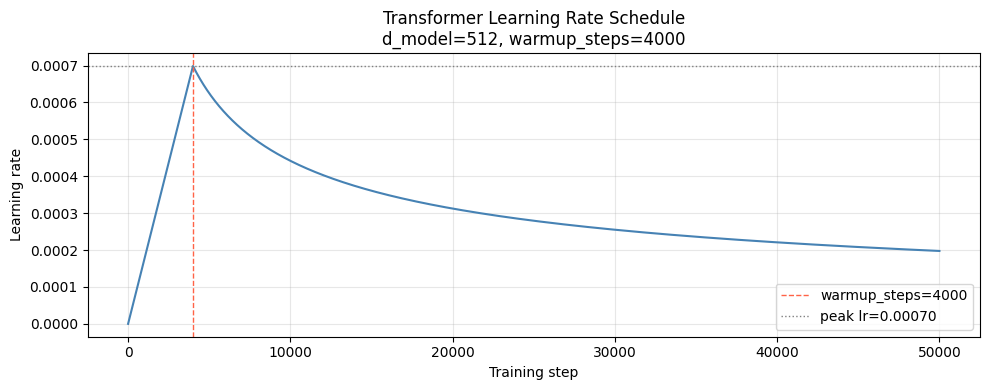

Learning rate schedule figure saved to:
/content/drive/MyDrive/Transformer_Mine/figures/lr_schedule.png


In [38]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, lrs, color='steelblue', linewidth=1.5)
ax.axvline(x=4000, color='tomato', linestyle='--',
           linewidth=1, label='warmup_steps=4000')
ax.axhline(y=peak_lr, color='gray', linestyle=':',
           linewidth=1, label=f'peak lr={peak_lr:.5f}')
ax.set_xlabel('Training step')
ax.set_ylabel('Learning rate')
ax.set_title('Transformer Learning Rate Schedule\n'
             'd_model=512, warmup_steps=4000')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = os.path.join(PROJECT_ROOT, 'figures', 'lr_schedule.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Learning rate schedule figure saved to:")
print(f"{fig_path}")

# 6: Optimizer

## Adam Optimizer

From the paper, Section 5.3, the Transformer uses the **Adam optimizer** with the following hyperparameters:

| Hyperparameter |  Value |
| -------------- | -----: |
| $\beta_1$      |  `0.9` |
| $\beta_2$      | `0.98` |
| $\epsilon$     | `1e-9` |

### Optimizer Configuration

```text
Adam(
    beta_1 = 0.9,
    beta_2 = 0.98,
    epsilon = 1e-9
)
```

### Important Implementation Note

The paper specifies:

```text
epsilon = 1e-9
```

This differs from the typical Keras default:

```text
epsilon = 1e-7
```

Therefore, the implementation should explicitly set:

```text
epsilon = 1e-9
```

rather than relying on the framework default.

### Why the Epsilon Value Matters

The $\epsilon$ term is used for numerical stability in Adam's adaptive update:

$$
\theta_{t+1}
=
\theta_t
-
\eta
\frac{\hat{m}_t}
{\sqrt{\hat{v}_t}+\epsilon}
$$

Using a different epsilon changes the denominator of the adaptive update and can therefore affect the effective parameter updates and convergence behaviour.

For faithful reproduction of the original Transformer, the paper's value should be preserved:

```text
Paper: epsilon = 1e-9
Keras default: epsilon = 1e-7
```


In [39]:
lr_schedule_main = TransformerLRSchedule(d_model=512, warmup_steps=4000)

optimizer = tf.keras.optimizers.Adam(
    learning_rate = lr_schedule_main,
    beta_1 = 0.9,
    beta_2 = 0.98,
    epsilon = 1e-9,
)

print("Optimizer: Adam")
print(f"beta_1 = 0.9")
print(f"beta_2 = 0.98")
print(f"epsilon = 1e-9  (paper value — not Keras default 1e-7)")
print(f"lr = TransformerLRSchedule(d_model=512, warmup_steps=4000)")

Optimizer: Adam
beta_1 = 0.9
beta_2 = 0.98
epsilon = 1e-9  (paper value — not Keras default 1e-7)
lr = TransformerLRSchedule(d_model=512, warmup_steps=4000)


# 7: Training Step

## Single Training Step

This cell implements a **single training step** for the Transformer model.

Each training step includes the following components:

1. **Teacher forcing**
2. **Label smoothing loss**
3. **Gradient clipping**
4. **Gradient application through the optimizer**

### 1. Teacher Forcing

During training, the decoder receives the **gold target prefix** rather than its own previous predictions.

```text id="p3q6qf"
Target sequence:

<BOS> Ich bin Student <EOS>

Decoder input:

<BOS> Ich bin Student

Expected output:

Ich bin Student <EOS>
```

This allows the model to learn the next-token prediction task efficiently.

### 2. Label Smoothing Loss

The training step uses the **label-smoothed loss** implemented in the previous cell.

```text id="7n2e6m"
Transformer logits
        |
        ↓
Label Smoothing Loss
        |
        ↓
Masked Loss
```

Padding positions are excluded from the loss calculation.

### 3. Gradient Clipping

Gradients are clipped by their global norm:

```text id="z5x0b4"
clip_norm = 1.0
```

Gradient clipping helps prevent excessively large gradient updates and improves training stability.

The gradients are conceptually processed as:

```text id="n4v9q1"
Gradients
    |
    ↓
Global Norm Clipping
    |
    ↓
Clipped Gradients
```

### 4. Gradient Application

After computing and clipping the gradients, they are applied to the model's trainable parameters using the configured optimizer.

```text id="b7m3xk"
Input Batch
    |
    ↓
Transformer Forward Pass
    |
    ↓
Logits
    |
    ↓
Label-Smoothing Loss
    |
    ↓
Gradient Computation
    |
    ↓
Gradient Clipping
    |  clip_norm = 1.0
    ↓
Optimizer
    |
    ↓
Updated Model Parameters
```

### Training Step Summary

The complete training step therefore follows:

```text id="v6wq8z"
Source + Target Batch
        |
        ↓
Encoder
        |
        ↓
Decoder with Gold Prefix
        |
        ↓
Logits
        |
        ↓
Label-Smoothed Loss
        |
        ↓
Backpropagation
        |
        ↓
Gradient Clipping (norm = 1.0)
        |
        ↓
Adam Optimizer
        |
        ↓
Parameter Update
```


In [40]:
@tf.function
def train_step(model, optimizer, src_ids, dec_input, dec_target, vocab_size):
    """
    Single training step.

    Args:
        model : TiedTransformer instance
        optimizer : Adam optimizer
        src_ids : (batch, src_len) — encoder input token IDs
        dec_input : (batch, tgt_len) — decoder input  [BOS, t1, t2, ...]
        dec_target : (batch, tgt_len) — decoder target [t1, t2, ..., EOS]
        vocab_size : integer

    Returns:
        loss : scalar training loss for this batch
    """
    with tf.GradientTape() as tape:
        logits, _ = model(
            src_ids,
            dec_input,
            training=True,
        )
        # logits shape: (batch, tgt_len, vocab_size)

        loss = label_smoothing_loss(
            logits,
            dec_target,
            vocab_size,
            smoothing=0.1,
        )

    # Compute gradients
    gradients = tape.gradient(loss, model.trainable_variables)

    # Clip gradients by global norm (prevents exploding gradients)
    gradients, _ = tf.clip_by_global_norm(gradients, clip_norm=1.0)

    # Apply gradients
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss

# 8: Checkpoint Manager

## Checkpoint Manager

This cell implements a **checkpoint manager** for saving and restoring the complete training state of the Transformer.

The checkpoint stores:

* **Model weights**
* **Optimizer state**
* **Global training step**

### Saved State

```text
Checkpoint
    |
    +-- Model Weights
    |
    +-- Optimizer State
    |      |
    |      +-- Step Count
    |      +-- Momentum / Moving Averages
    |
    +-- Global Step
```

### Why Optimizer State Must Be Saved

Saving only the model weights is not sufficient when training needs to be resumed.

The Adam optimizer maintains internal state, including its moving-average terms and optimization step. Restoring this state allows training to continue from the same optimisation state rather than starting with a fresh optimizer.

### Learning Rate Schedule

The Transformer learning-rate schedule depends directly on the training step:

```text
learning_rate = f(global_step)
```

Therefore, restoring the correct **global step** is essential when resuming training.

For example:

```text
Colab Disconnect
      |
      ↓
Restore Checkpoint
      |
      +------> Model Weights
      |
      +------> Optimizer State
      |
      +------> Global Step
      |
      ↓
Continue Training
```

Without restoring the optimizer state and step count, training would not continue from exactly the same optimisation state, and the learning rate could be inconsistent with the intended schedule.



In [41]:
def create_checkpoint_manager(model, optimizer, checkpoint_dir, max_to_keep=5):
    """
    Create a TensorFlow checkpoint manager.

    Args:
        model : Transformer model
        optimizer : Adam optimizer
        checkpoint_dir : directory to save checkpoints
        max_to_keep : number of recent checkpoints to keep

    Returns:
        ckpt : tf.train.Checkpoint object
        manager : tf.train.CheckpointManager object
    """
    ckpt = tf.train.Checkpoint(
        model = model,
        optimizer = optimizer,
    )
    manager = tf.train.CheckpointManager(
        ckpt,
        directory = checkpoint_dir,
        max_to_keep = max_to_keep,
    )
    return ckpt, manager


In [42]:


def restore_checkpoint(ckpt, manager):
    """
    Restore the latest checkpoint if one exists.

    Args:
        ckpt : tf.train.Checkpoint object
        manager : tf.train.CheckpointManager object

    Returns:
        restored : True if a checkpoint was restored, False otherwise
    """
    if manager.latest_checkpoint:
        ckpt.restore(manager.latest_checkpoint)
        print(f"Restored checkpoint: {manager.latest_checkpoint}")
        return True
    else:
        print("No checkpoint found. Starting from scratch.")
        return False

# 9: Experiment Logger

Maintains a CSV log of training metrics as required by the project spec (Section 34).


In [43]:
RESULTS_CSV = os.path.join(EXPERIMENTS_DIR, 'results.csv')

In [44]:
FIELDNAMES = [
    'experiment_id', 'model_config', 'dataset', 'dataset_size',
    'epochs', 'steps', 'batch_size', 'd_model', 'num_heads',
    'num_layers', 'd_ff', 'dropout', 'label_smoothing',
    'learning_rate', 'warmup_steps', 'parameters', 'gpu',
    'training_time', 'validation_loss', 'BLEU', 'checkpoint', 'notes',
]

In [45]:
def init_results_csv(path):
    """Create results CSV with headers if it does not exist."""
    if not os.path.exists(path):
        with open(path, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
            writer.writeheader()
        print(f"Results CSV created: {path}")
    else:
        print(f"Results CSV already exists: {path}")

In [46]:
def log_experiment(path, record):
    """
    Append one experiment record to the results CSV.

    Args:
        path : path to results CSV
        record : dict with keys matching FIELDNAMES
                 missing keys are filled with empty string
    """
    row = {k: record.get(k, '') for k in FIELDNAMES}
    with open(path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writerow(row)
    print(f"Experiment logged: {record.get('experiment_id', 'unknown')}")


In [47]:
init_results_csv(RESULTS_CSV)

Results CSV created: /content/drive/MyDrive/Transformer_Mine/experiments/results.csv


# 10: Full Training Loop

Complete training loop with:

* checkpoint saving every N steps
* validation loss computation
* per-step loss logging
* session recovery support
* estimated time remaining


In [48]:
from logging import Manager


In [49]:
def compute_validation_loss(model, val_dataset, vocab_size, max_batches=20):
    """
    Compute mean validation loss over a limited number of batches.

    Args:
        model : TiedTransformer
        val_dataset : tf.data.Dataset
        vocab_size : integer
        max_batches : max batches to evaluate (keeps it fast)

    Returns:
        mean validation loss (float)
    """
    total_loss = 0.0
    n_batches = 0

    for enc_input, dec_input, dec_target in val_dataset.take(max_batches):
        logits, _ = model(enc_input, dec_input, training=False)
        loss = label_smoothing_loss(logits, dec_target, vocab_size, smoothing=0.1)
        total_loss += loss.numpy()
        n_batches += 1

    return total_loss / n_batches if n_batches > 0 else float('inf')

In [50]:
def train(
    model,
    optimizer,
    train_dataset,
    val_dataset,
    vocab_size,
    checkpoint_dir,
    total_steps,
    checkpoint_every=500,
    validate_every=500,
    log_every=50,
    initial_step=0,
):
    """
    Full training loop with checkpointing and session recovery.

    Args:
        model : TiedTransformer
        optimizer : Adam with LR schedule
        train_dataset : tf.data.Dataset yielding
                           (enc_input, dec_input, dec_target)
        val_dataset : tf.data.Dataset for validation
        vocab_size : integer
        checkpoint_dir : path to save checkpoints
        total_steps : total training steps to run
        checkpoint_every : save checkpoint every N steps
        validate_every : compute validation loss every N steps
        log_every : print loss every N steps
        initial_step : starting step (for resumed training)

    Returns:
        history : dict with 'step', 'train_loss', 'val_loss'
    """

    ckpt, manager = create_checkpoint_manager(model, optimizer, checkpoint_dir)

    restored = restore_checkpoint(ckpt, manager)

    if restored:
        current_step = optimizer.iterations.numpy()
    else:
        current_step = initial_step

    history = {
        'step' : [],
        'train_loss' : [],
        'val_loss' : [],
    }

    dataset_iter = iter(train_dataset.repeat())
    step = current_step
    t_start = time.time()

    print(f"\nTraining from step {step} to {total_steps}")
    print(f"checkpoint every : {checkpoint_every} steps")
    print(f"validate every : {validate_every} steps")
    print(f"log every : {log_every} steps")
    print()

    while step < total_steps:
        enc_input, dec_input, dec_target = next(dataset_iter)

        loss = train_step(
            model,
            optimizer,
            enc_input,
            dec_input,
            dec_target,
            vocab_size,
        )

        step += 1

        # Log training loss
        if step % log_every == 0:
            elapsed = time.time() - t_start
            steps_done = step - current_step
            steps_left = total_steps - step
            sps = steps_done / elapsed if elapsed > 0 else 0
            eta = steps_left / sps if sps > 0 else 0
            lr_now = optimizer.learning_rate(step).numpy()

            print(f"step {step:>6}  "
                  f"loss={loss.numpy():.4f}  "
                  f"lr={lr_now:.6f}  "
                  f"elapsed={elapsed:.0f}s  "
                  f"eta={eta:.0f}s")

            history['step'].append(step)
            history['train_loss'].append(float(loss.numpy()))

        # Validation loss
        if step % validate_every == 0:
            val_loss = compute_validation_loss(
                model, val_dataset, vocab_size, max_batches=20
            )

            print(f"validation loss at step {step}: {val_loss:.4f}")
            history['val_loss'].append((step, float(val_loss)))

        if step % checkpoint_every == 0:
            save_path = manager.save()
            print(f"checkpoint saved: {save_path}")

    # Final checkpoint
    save_path = manager.save()
    print(f"\nTraining complete. Final checkpoint: {save_path}")

    return history

# 11: Smoke Test — 100 Steps

Before any serious training, run 100 steps to verify:

* loss decreases
* no OOM errors
* checkpoint saves correctly
* learning rate follows schedule


In [51]:
VOCAB_DIR_A = os.path.join(PROJECT_ROOT, 'vocab/stage_a')
STAGE_A_DIR = os.path.join(PROJECT_ROOT, 'datasets/stage_a')
SMOKE_CKPT = os.path.join(CHECKPOINT_DIR, 'smoke_test')

In [52]:
tokenizer_a = BPETokenizer.load(VOCAB_DIR_A)
src_a, tgt_a = load_raw_pairs(
    os.path.join(STAGE_A_DIR, 'train.en'),
    os.path.join(STAGE_A_DIR, 'train.de'),
)

In [53]:
VOCAB_SIZE_A = tokenizer_a.vocab_size
MAX_LEN_A = 20
BATCH_SIZE_A = 4

In [54]:
dataset_smoke = build_tf_dataset(
    src_lines = src_a,
    tgt_lines = tgt_a,
    encode_fn = tokenizer_a.encode,
    max_len = MAX_LEN_A,
    batch_size = BATCH_SIZE_A,
    bos_id = tokenizer_a.bos_id,
    eos_id = tokenizer_a.eos_id,
    pad_id = tokenizer_a.pad_id,
)

In [55]:
smoke_model = TiedTransformer(
    num_layers = 2,
    d_model = 128,
    num_heads = 4,
    d_ff = 512,
    src_vocab = VOCAB_SIZE_A,
    tgt_vocab = VOCAB_SIZE_A,
    dropout = 0.1,
)

In [56]:
smoke_lr = TransformerLRSchedule(d_model=128, warmup_steps=100)
smoke_opt = tf.keras.optimizers.Adam(
    learning_rate = smoke_lr,
    beta_1 = 0.9,
    beta_2 = 0.98,
    epsilon = 1e-9,
)

In [59]:
# Run 100 steps
t0 = time.time()
dataset_rep = iter(dataset_smoke.repeat())
losses = []

for step in range(1, 101):
    enc_in, dec_in, dec_tgt = next(dataset_rep)
    loss = train_step(
        smoke_model, smoke_opt,
        enc_in, dec_in, dec_tgt,
        VOCAB_SIZE_A,
    )
    losses.append(loss.numpy())

    if step % 20 == 0:
        # Directly access the learning rate as it is already an EagerTensor tracking the value
        lr_now = float(smoke_opt.learning_rate.numpy())
        print(f"step {step:>4}  loss={loss.numpy():.4f}  lr={lr_now:.6f}")

elapsed = time.time() - t0

print(f"\nSmoke test complete in {elapsed:.1f}s")
print(f"Initial loss : {losses[0]:.4f}")
print(f"Final loss : {losses[-1]:.4f}")
print(f"Loss trend : {'decreasing' if losses[-1] < losses[0] else 'not decreasing'}")

# Check loss is finite
assert all(np.isfinite(l) for l in losses), "NaN or Inf loss detected"
print("All losses finite - correct")

step   20  loss=3.2472  lr=0.005303
step   40  loss=3.0703  lr=0.007071
step   60  loss=3.0257  lr=0.008839
step   80  loss=3.3276  lr=0.008069
step  100  loss=2.8784  lr=0.007470

Smoke test complete in 4.8s
Initial loss : 3.6329
Final loss : 2.8784
Loss trend : decreasing
All losses finite - correct


#12: Save Training Utilities to Drive

In [60]:
TRAINING_PY = os.path.join(PROJECT_ROOT, 'training.py')

In [65]:
code = '''"""
training.py - Training utilities
Transformer Reproduction Project - Phase 11

Usage:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Transformer_Mine
    from training import (
        label_smoothing_loss,
        TransformerLRSchedule,
        train_step,
        train,
        compute_validation_loss,
        create_checkpoint_manager,
        restore_checkpoint,
    )
"""

import os
import time
import csv
import numpy as np
import tensorflow as tf

PAD_ID = 0


def label_smoothing_loss(logits, targets, vocab_size, smoothing=0.1, pad_id=PAD_ID):
    one_hot = tf.one_hot(targets, depth=vocab_size, dtype=tf.float32)
    smoothed = one_hot * (1.0 - smoothing) + (smoothing / vocab_size)
    log_probs = tf.nn.log_softmax(logits, axis=-1)
    loss_per_token = -tf.reduce_sum(smoothed * log_probs, axis=-1)
    non_pad_mask = tf.cast(tf.not_equal(targets, pad_id), dtype=tf.float32)
    loss_per_token = loss_per_token * non_pad_mask
    num_tokens = tf.reduce_sum(non_pad_mask)
    return tf.reduce_sum(loss_per_token) / num_tokens


class TransformerLRSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)

    def __call__(self, step):
        step = tf.maximum(tf.cast(step, tf.float32), 1.0)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * tf.math.pow(self.warmup_steps, -1.5)
        return tf.math.rsqrt(self.d_model) * tf.minimum(arg1, arg2)

    def get_config(self):
        return {"d_model": int(self.d_model.numpy()),
                "warmup_steps": int(self.warmup_steps.numpy())}


@tf.function
def train_step(model, optimizer, src_ids, dec_input, dec_target, vocab_size):
    with tf.GradientTape() as tape:
        logits, _ = model(src_ids, dec_input, training=True)
        loss = label_smoothing_loss(logits, dec_target, vocab_size)
    gradients, _ = tf.clip_by_global_norm(
        tape.gradient(loss, model.trainable_variables), 1.0)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss


def create_checkpoint_manager(model, optimizer, checkpoint_dir, max_to_keep=5):
    ckpt = tf.train.Checkpoint(model=model, optimizer=optimizer)
    manager = tf.train.CheckpointManager(ckpt, checkpoint_dir,
                                          max_to_keep=max_to_keep)
    return ckpt, manager


def restore_checkpoint(ckpt, manager):
    if manager.latest_checkpoint:
        ckpt.restore(manager.latest_checkpoint)
        print(f"Restored: {manager.latest_checkpoint}")
        return True
    print("No checkpoint found. Starting from scratch.")
    return False


def compute_validation_loss(model, val_dataset, vocab_size, max_batches=20):
    total, n = 0.0, 0
    for enc_input, dec_input, dec_target in val_dataset.take(max_batches):
        logits, _ = model(enc_input, dec_input, training=False)
        total += label_smoothing_loss(logits, dec_target, vocab_size).numpy()
        n += 1
    return total / n if n > 0 else float("inf")


def train(model, optimizer, train_dataset, val_dataset, vocab_size,
          checkpoint_dir, total_steps, checkpoint_every=500,
          validate_every=500, log_every=50, initial_step=0):
    ckpt, manager = create_checkpoint_manager(model, optimizer, checkpoint_dir)
    restored = restore_checkpoint(ckpt, manager)
    current_step = optimizer.iterations.numpy() if restored else initial_step
    history = {"step": [], "train_loss": [], "val_loss": []}
    dataset_iter = iter(train_dataset.repeat())
    step, t_start = current_step, time.time()

    while step < total_steps:
        enc_input, dec_input, dec_target = next(dataset_iter)
        loss = train_step(model, optimizer, enc_input,
                          dec_input, dec_target, vocab_size)
        step += 1

        if step % log_every == 0:
            elapsed = time.time() - t_start
            steps_done = step - current_step
            sps = steps_done / elapsed if elapsed > 0 else 0
            eta = (total_steps - step) / sps if sps > 0 else 0
            lr_now = optimizer.learning_rate(step).numpy()
            print(f"step {step:>6}  loss={loss.numpy():.4f}  "
                  f"lr={lr_now:.6f}  elapsed={elapsed:.0f}s  eta={eta:.0f}s")
            history["step"].append(step)
            history["train_loss"].append(float(loss.numpy()))

        if step % validate_every == 0:
            val_loss = compute_validation_loss(model, val_dataset, vocab_size)
            print(f"val loss at step {step}: {val_loss:.4f}")
            history["val_loss"].append((step, float(val_loss)))

        if step % checkpoint_every == 0:
            print(f"checkpoint saved: {manager.save()}")

    print(f"Training complete. Final checkpoint: {manager.save()}")
    return history
'''





In [66]:
with open(TRAINING_PY, 'w', encoding='utf-8') as f:
    f.write(code)